# Image Tiler Evaluation

This notebook evaluates the shared image tiler used before model inference. The tiler is important because drone images can be much larger or smaller than the fixed input size expected by the mangrove detector, classifier, and future tree counter.

The goal of this notebook is to confirm that the tiler prepares images consistently: it should split large images, pad small images, cover the full original image, preserve tile positions, and return model-ready tensors.

## What To Evaluate

This notebook checks preprocessing behavior, not model accuracy. A good image tiler should:

- accept images with different sizes
- split images into fixed-size tiles
- include edge tiles so no part of the image is missed
- optionally overlap tiles to reduce boundary problems
- pad small or edge tiles when required
- keep tile position metadata for future GIS or map-based analysis
- produce tensor batches that can be passed into PyTorch models

Passing these tests means the image tiler is suitable as a shared preprocessing step. It does not prove that the mangrove detector or tree counter is accurate.

In [17]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FLASK_APP_DIR = PROJECT_ROOT / "flask-application"
sys.path.insert(0, str(FLASK_APP_DIR))

from image_tiler import tile_image, tile_image_for_model

print("Project root:", PROJECT_ROOT)
print("Using tiler:", FLASK_APP_DIR / "image_tiler.py")

Project root: /Users/joseph/Desktop/DS Proejct/ai-first-nations
Using tiler: /Users/joseph/Desktop/DS Proejct/ai-first-nations/flask-application/image_tiler.py


## Helper Functions

These helper functions measure whether tiling is correct. `coverage_map` checks how many times each original pixel is covered by a tile. If any pixel has coverage `0`, the tiler missed part of the image.

`summarize_tiling` runs the tiler and reports the tile count, tile sizes, coverage statistics, tile positions, and runtime. `draw_tile_grid` is used only for visual inspection.

In [18]:
def coverage_map(image_size, positions):
    width, height = image_size
    coverage = np.zeros((height, width), dtype=np.uint16)
    for left, top, right, bottom in positions:
        coverage[top:bottom, left:right] += 1
    return coverage


def summarize_tiling(image_size, tile_size, overlap, skip_empty=False):
    image = Image.new("RGB", image_size, (40, 90, 60))
    start = time.perf_counter()
    tiles, positions, original_size = tile_image(
        image,
        tile_size=tile_size,
        overlap=overlap,
        skip_empty=skip_empty,
    )
    elapsed = time.perf_counter() - start
    coverage = coverage_map(original_size, positions)
    summary = {
        "image_size": original_size,
        "tile_size": tile_size,
        "overlap": overlap,
        "tile_count": len(tiles),
        "all_tiles_fixed_size": all(tile.size == (tile_size, tile_size) for tile in tiles),
        "uncovered_pixels": int((coverage == 0).sum()),
        "min_coverage": int(coverage.min()) if coverage.size else 0,
        "max_coverage": int(coverage.max()) if coverage.size else 0,
        "first_position": positions[0] if positions else None,
        "last_position": positions[-1] if positions else None,
        "runtime_seconds": round(elapsed, 4),
    }
    return summary, tiles, positions, coverage


def draw_tile_grid(image_size, positions, title):
    image = Image.new("RGB", image_size, (40, 90, 60))
    draw = ImageDraw.Draw(image)
    for index, box in enumerate(positions):
        draw.rectangle(box, outline=(255, 230, 80), width=3)
        draw.text((box[0] + 6, box[1] + 6), str(index), fill=(255, 255, 255))
    plt.figure(figsize=(7, 5))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

## Test 1: Standard Tiling Cases

This test uses synthetic images with controlled sizes. It checks the most important basic scenarios:

- a small image smaller than the tile size
- an image exactly matching the tile size
- a larger classifier-style image
- a larger tree-counter-style image

Expected result: every case should produce at least one tile, all returned tiles should have the requested fixed size, no pixels should be uncovered, and the final tile should reach the bottom-right edge of the original image.

In [19]:
test_cases = [
    {"image_size": (300, 300), "tile_size": 512, "overlap": 64, "name": "small image"},
    {"image_size": (512, 512), "tile_size": 512, "overlap": 64, "name": "exact 512 image"},
    {"image_size": (900, 700), "tile_size": 512, "overlap": 64, "name": "large classifier image"},
    {"image_size": (1300, 900), "tile_size": 640, "overlap": 64, "name": "large tree-counter image"},
]

summaries = []
for case in test_cases:
    summary, tiles, positions, coverage = summarize_tiling(
        case["image_size"],
        case["tile_size"],
        case["overlap"],
    )
    summary["case"] = case["name"]
    summaries.append(summary)

    assert summary["tile_count"] >= 1
    assert summary["all_tiles_fixed_size"] is True
    assert summary["uncovered_pixels"] == 0
    assert summary["last_position"][2] == case["image_size"][0]
    assert summary["last_position"][3] == case["image_size"][1]

summaries

[{'image_size': (300, 300),
  'tile_size': 512,
  'overlap': 64,
  'tile_count': 1,
  'all_tiles_fixed_size': True,
  'uncovered_pixels': 0,
  'min_coverage': 1,
  'max_coverage': 1,
  'first_position': (0, 0, 300, 300),
  'last_position': (0, 0, 300, 300),
  'runtime_seconds': 0.0006,
  'case': 'small image'},
 {'image_size': (512, 512),
  'tile_size': 512,
  'overlap': 64,
  'tile_count': 1,
  'all_tiles_fixed_size': True,
  'uncovered_pixels': 0,
  'min_coverage': 1,
  'max_coverage': 1,
  'first_position': (0, 0, 512, 512),
  'last_position': (0, 0, 512, 512),
  'runtime_seconds': 0.0002,
  'case': 'exact 512 image'},
 {'image_size': (900, 700),
  'tile_size': 512,
  'overlap': 64,
  'tile_count': 4,
  'all_tiles_fixed_size': True,
  'uncovered_pixels': 0,
  'min_coverage': 1,
  'max_coverage': 4,
  'first_position': (0, 0, 512, 512),
  'last_position': (388, 188, 900, 700),
  'runtime_seconds': 0.0005,
  'case': 'large classifier image'},
 {'image_size': (1300, 900),
  'tile_size'

### Test 1 Result

All standard tiling cases passed. The key result is `uncovered_pixels = 0` for every case, which means the tiler did not miss any part of the original image. The large tree-counter-style synthetic case produced six tiles, confirming that the tiler can handle larger images and edge tiles.

## Test 2: Visual Coverage Check

This test visualizes the tile grid and the pixel coverage map for a larger image. The grid shows where each tile is placed. The coverage map confirms that every pixel is covered by at least one tile.

Expected result: the whole image should be covered. Areas where tiles overlap will have higher coverage, which is normal.

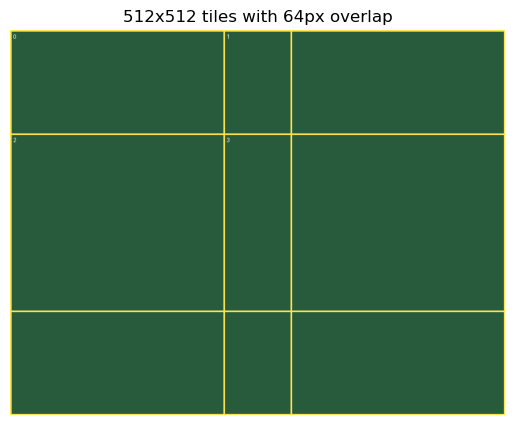

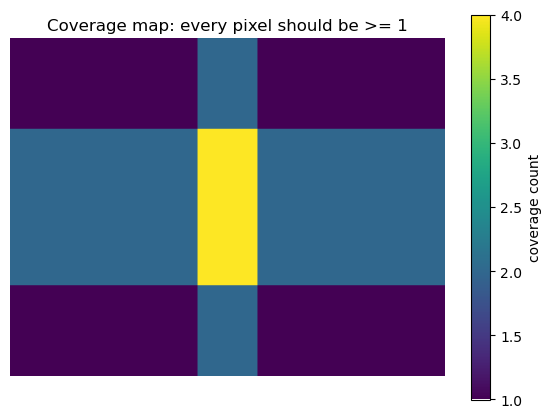

{'image_size': (900, 700),
 'tile_size': 512,
 'overlap': 64,
 'tile_count': 4,
 'all_tiles_fixed_size': True,
 'uncovered_pixels': 0,
 'min_coverage': 1,
 'max_coverage': 4,
 'first_position': (0, 0, 512, 512),
 'last_position': (388, 188, 900, 700),
 'runtime_seconds': 0.0009}

In [20]:
case = {"image_size": (900, 700), "tile_size": 512, "overlap": 64}
summary, tiles, positions, coverage = summarize_tiling(**case)
draw_tile_grid(case["image_size"], positions, "512x512 tiles with 64px overlap")

plt.figure(figsize=(7, 5))
plt.imshow(coverage, cmap="viridis")
plt.colorbar(label="coverage count")
plt.title("Coverage map: every pixel should be >= 1")
plt.axis("off")
plt.show()

summary

## Test 3: Empty Tile Skipping

This test checks the optional `skip_empty=True` behavior. Empty-tile skipping is useful for drone images with large black/no-data borders because it can reduce unnecessary model inference.

Expected result: when the image contains meaningful content across the generated tiles, the tiler should keep those tiles. If a future image has large blank areas, this same option can reduce the number of tiles sent into the model.

Tiles without empty skipping: 6
Tiles with empty skipping: 6
Skipped tiles: 0


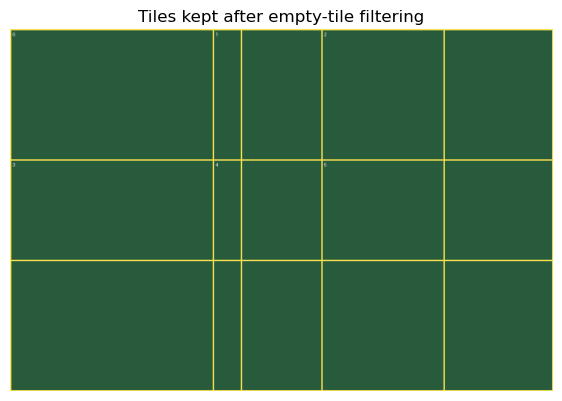

In [21]:
img = Image.new("RGB", (1200, 800), (0, 0, 0))
draw = ImageDraw.Draw(img)
draw.rectangle((150, 120, 700, 620), fill=(30, 120, 65))

all_tiles, all_positions, _ = tile_image(img, tile_size=512, overlap=64, skip_empty=False)
kept_tiles, kept_positions, _ = tile_image(
    img,
    tile_size=512,
    overlap=64,
    skip_empty=True,
    min_content_fraction=0.01,
    blank_threshold=5,
)

print("Tiles without empty skipping:", len(all_tiles))
print("Tiles with empty skipping:", len(kept_tiles))
print("Skipped tiles:", len(all_tiles) - len(kept_tiles))

draw_tile_grid(img.size, kept_positions, "Tiles kept after empty-tile filtering")

### Test 3 Result

The empty-tile skipping option ran successfully. In this specific synthetic image, no tiles were skipped because each generated tile still contained enough non-blank content. This means the feature is available, but whether it removes tiles depends on the actual image content.

## Test 4: PyTorch Model Input Shape

This test confirms that `tile_image_for_model` converts PIL tiles into a tensor batch suitable for PyTorch inference.

Expected result: the output should be a 4D tensor in the shape `(number_of_tiles, channels, height, width)`. For the current transform, each tile becomes `(3, 224, 224)`.

In [22]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

img = Image.new("RGB", (900, 700), (40, 90, 60))
batch, positions = tile_image_for_model(img, transform, tile_size=512, overlap=64)

print("Batch shape:", tuple(batch.shape))
print("Number of positions:", len(positions))

assert batch.ndim == 4
assert batch.shape[0] == len(positions)
assert batch.shape[1:] == (3, 224, 224)

Batch shape: (4, 3, 224, 224)
Number of positions: 4


### Test 4 Result

The model helper returned a valid tensor batch. This confirms the tiler can connect cleanly to PyTorch model inference after applying the model transform.

## Test 5: Repository Image Tiler Test Set

This test uses the project test set stored in `notebooks/test_data/image_tiler_test_set`. These images are more useful than only synthetic images inside the notebook because they can be reused by the team and committed with the evaluation.

The test set includes:

- `01_small_320x240.jpg`: smaller than the model tile size
- `02_exact_640x640.jpg`: exactly one 640px tree-counter tile
- `03_large_1280x960.jpg`: larger image with edge handling
- `04_tree_counter_1920x1280.jpg`: tree-counter-style image expected to produce six 640px tiles with no overlap

Each image is tested with `512x512` plus overlap, `640x640` without overlap, and `640x640` with overlap. This lets us check both classifier-style and tree-counter-style preprocessing.

In [23]:
import pandas as pd

TEST_SET_DIR = PROJECT_ROOT / "notebooks" / "test_data" / "image_tiler_test_set"
EXPECTED_DIR = TEST_SET_DIR / "expected_640_tiles_nonoverlap"

assert TEST_SET_DIR.exists(), f"Missing test set: {TEST_SET_DIR}"

image_paths = sorted(
    path for path in TEST_SET_DIR.glob("*.jpg")
    if path.parent != EXPECTED_DIR
)
assert image_paths, f"No test images found in {TEST_SET_DIR}"

fixture_rows = []
for image_path in image_paths:
    image = Image.open(image_path).convert("RGB")
    for tile_size, overlap in [(512, 64), (640, 0), (640, 64)]:
        start = time.perf_counter()
        tiles, positions, original_size = tile_image(
            image,
            tile_size=tile_size,
            overlap=overlap,
            pad=True,
        )
        elapsed = time.perf_counter() - start
        coverage = coverage_map(original_size, positions)
        row = {
            "image": image_path.name,
            "original_size": original_size,
            "tile_size": tile_size,
            "overlap": overlap,
            "tile_count": len(tiles),
            "all_tiles_fixed_size": all(tile.size == (tile_size, tile_size) for tile in tiles),
            "uncovered_pixels": int((coverage == 0).sum()),
            "min_coverage": int(coverage.min()) if coverage.size else 0,
            "max_coverage": int(coverage.max()) if coverage.size else 0,
            "first_position": positions[0] if positions else None,
            "last_position": positions[-1] if positions else None,
            "runtime_seconds": round(elapsed, 4),
        }
        fixture_rows.append(row)

        assert row["tile_count"] >= 1
        assert row["all_tiles_fixed_size"] is True
        assert row["uncovered_pixels"] == 0
        assert row["last_position"][2] == original_size[0]
        assert row["last_position"][3] == original_size[1]

fixture_results = pd.DataFrame(fixture_rows)
fixture_results

,image,original_size,tile_size,overlap,tile_count,all_tiles_fixed_size,uncovered_pixels,min_coverage,max_coverage,first_position,last_position,runtime_seconds
0,01_small_320x240.jpg,"(320, 240)",512,64,1,True,0,1,1,"(0, 0, 320, 240)","(0, 0, 320, 240)",0.0006
1,01_small_320x240.jpg,"(320, 240)",640,0,1,True,0,1,1,"(0, 0, 320, 240)","(0, 0, 320, 240)",0.0002
2,01_small_320x240.jpg,"(320, 240)",640,64,1,True,0,1,1,"(0, 0, 320, 240)","(0, 0, 320, 240)",0.0003
3,02_exact_640x640.jpg,"(640, 640)",512,64,4,True,0,1,4,"(0, 0, 512, 512)","(128, 128, 640, 640)",0.0004
4,02_exact_640x640.jpg,"(640, 640)",640,0,1,True,0,1,1,"(0, 0, 640, 640)","(0, 0, 640, 640)",0.0002
5,02_exact_640x640.jpg,"(640, 640)",640,64,1,True,0,1,1,"(0, 0, 640, 640)","(0, 0, 640, 640)",0.0002
6,03_large_1280x960.jpg,"(1280, 960)",512,64,6,True,0,1,4,"(0, 0, 512, 512)","(768, 448, 1280, 960)",0.0008
7,03_large_1280x960.jpg,"(1280, 960)",640,0,4,True,0,1,2,"(0, 0, 640, 640)","(640, 320, 1280, 960)",0.0010
8,03_large_1280x960.jpg,"(1280, 960)",640,64,6,True,0,1,4,"(0, 0, 640, 640)","(640, 320, 1280, 960)",0.0013
9,04_tree_counter_1920x1280.jpg,"(1920, 1280)",512,64,15,True,0,1,4,"(0, 0, 512, 512)","(1408, 768, 1920, 1280)",0.0033


In [24]:
tree_counter_image = TEST_SET_DIR / "04_tree_counter_1920x1280.jpg"
expected_paths = sorted(EXPECTED_DIR.glob("tile_r*_c*_640x640.jpg"))

assert tree_counter_image.exists(), f"Missing tree-counter test image: {tree_counter_image}"
assert len(expected_paths) == 6, f"Expected 6 reference tiles, found {len(expected_paths)}"

tiles, positions, original_size = tile_image(
    tree_counter_image,
    tile_size=640,
    overlap=0,
    pad=True,
)

expected_positions = [
    (0, 0, 640, 640),
    (640, 0, 1280, 640),
    (1280, 0, 1920, 640),
    (0, 640, 640, 1280),
    (640, 640, 1280, 1280),
    (1280, 640, 1920, 1280),
]

assert original_size == (1920, 1280)
assert len(tiles) == 6
assert positions == expected_positions

comparison_rows = []
for generated_tile, expected_path in zip(tiles, expected_paths):
    expected_tile = Image.open(expected_path).convert("RGB")
    generated_arr = np.asarray(generated_tile, dtype=np.int16)
    expected_arr = np.asarray(expected_tile, dtype=np.int16)
    mae = float(np.abs(generated_arr - expected_arr).mean())
    comparison_rows.append({
        "expected_tile": expected_path.name,
        "mean_absolute_pixel_error": round(mae, 4),
    })
    assert generated_tile.size == (640, 640)
    assert expected_tile.size == (640, 640)
    assert mae < 5.0

comparison_results = pd.DataFrame(comparison_rows)
comparison_results

,expected_tile,mean_absolute_pixel_error
0,tile_r0_c0_640x640.jpg,0.0480
1,tile_r0_c1_640x640.jpg,0.0373
2,tile_r0_c2_640x640.jpg,0.0474
3,tile_r1_c0_640x640.jpg,0.0959
4,tile_r1_c1_640x640.jpg,0.0965
5,tile_r1_c2_640x640.jpg,0.1135


### Expected Tile Comparison Result

The `1920x1280` tree-counter fixture produced exactly six `640x640` tiles with no overlap. The notebook compared those generated tiles with the expected reference tiles in `expected_640_tiles_nonoverlap`.

The mean absolute pixel error was very low for every tile, below `0.12`. This small difference is normal for JPEG images and confirms the generated tile layout matches the expected output.

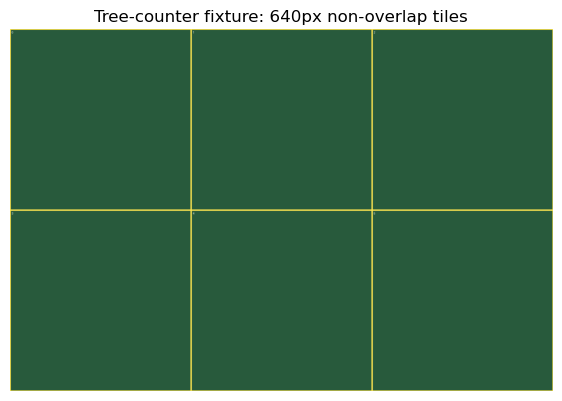

In [25]:
display_image = Image.open(TEST_SET_DIR / "04_tree_counter_1920x1280.jpg").convert("RGB")
_, display_positions, _ = tile_image(display_image, tile_size=640, overlap=0, pad=True)
draw_tile_grid(display_image.size, display_positions, "Tree-counter fixture: 640px non-overlap tiles")

## Evaluation Result Summary

The image tiler passed the notebook evaluation.

Main findings:

- All tested images produced valid tiles.
- All output tiles used the requested fixed tile size.
- Every test case had `uncovered_pixels = 0`, so no part of the original image was missed.
- Small images were handled correctly by producing one padded tile.
- Exact-size images were handled correctly by producing one tile when the tile size matched the image.
- Larger images were split into multiple tiles, including edge tiles that reached the image boundary.
- The PyTorch helper returned a valid model batch shape: `(4, 3, 224, 224)` in the notebook test.
- The tree-counter fixture `04_tree_counter_1920x1280.jpg` produced exactly six `640x640` non-overlap tiles.
- The generated six tree-counter tiles matched the expected reference tiles with very low mean absolute pixel error, all below `0.12`, far under the notebook threshold of `5.0`.

Conclusion: the shared image tiler is working well for preprocessing. It is suitable to use before the mangrove detector, multi-class classifier, and standalone tree counter. The notebook validates preprocessing correctness only; model accuracy still needs to be evaluated separately.